# Softmax Regression using TensorFlow

Softmax regression (or multinomial logistic regression) is a generalization of logistic regression to the case where we want to handle multiple classes in the target column. In binary logistic regression, the labels were binary. { 0, 1 } 

But a scenario where we need to classify an observation out of three or more class labels. For example, in digit classification here, the possible labels are: { 0, 1, 2, 3, 4, 5, 6, 7, 8, 9}. 
We use Softmax Regression.

In [9]:
import tensorflow as tf
import tensorflow.compat.v1 as tf1
import tensorflow.keras.datasets as tsd
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
data = tsd.mnist.load_data()


In [17]:
(X_train, Y_train),\
(X_val, Y_val) = data
print("Shape of feature matrix:", X_train.shape)
print("Shape of target matrix:", Y_train.shape)

Shape of feature matrix: (60000, 28, 28)
Shape of target matrix: (60000,)


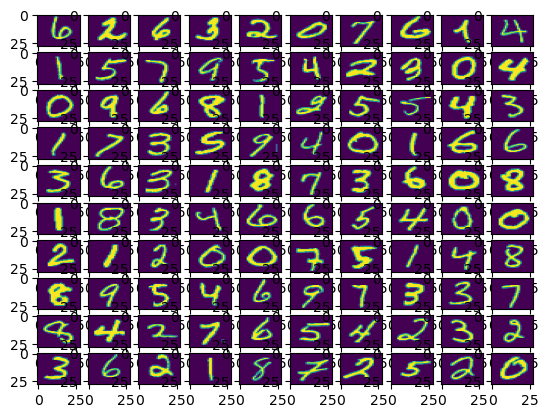

In [19]:
# visualize data by plotting images
fig, ax = plt.subplots(10, 10)
for i in range(10):
    for j in range(10):
        k = np.random.randint(0,X_train.shape[0])
        ax[i][j].imshow(X_train[k].reshape(28, 28),
                        aspect='auto')
plt.show()

In [21]:
num_features = 784
num_labels = 10
learning_rate = 0.05
batch_size = 128
num_steps = 5001
 
# input data
train_dataset = X_train.reshape(-1, 784)
train_labels = pd.get_dummies(Y_train).values
valid_dataset = X_val.reshape(-1, 784)
valid_labels = pd.get_dummies(Y_val).values

In [23]:
# initialize a tensorflow graph
graph = tf.Graph()
 
with graph.as_default():
    # Inputs
    tf_train_dataset = tf1.placeholder(tf.float32,
                                       shape=(batch_size, num_features))
    tf_train_labels = tf1.placeholder(tf.float32,
                                      shape=(batch_size, num_labels))
    tf_valid_dataset = tf.constant(valid_dataset)
 
    # Variables.
    weights = tf.Variable(
        tf.random.truncated_normal([num_features, num_labels]))
    biases = tf.Variable(tf.zeros([num_labels]))
 
    # Training computation.
    logits = tf.matmul(tf_train_dataset, weights) + biases
    loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(
        labels=tf_train_labels, logits=logits))
 
    # Optimizer.
    optimizer = tf1.train.GradientDescentOptimizer(
        learning_rate).minimize(loss)
 
    # Predictions for the training, validation, and test data.
    train_prediction = tf.nn.softmax(logits)
    tf_valid_dataset = tf.cast(tf_valid_dataset, tf.float32)
    valid_prediction = tf.nn.softmax(
        tf.matmul(tf_valid_dataset, weights) + biases)

In [25]:
# utility function to calculate accuracy
def accuracy(predictions, labels):
    correctly_predicted = np.sum(
        np.argmax(predictions, 1) == np.argmax(labels, 1))
    acc = (100.0 * correctly_predicted) / predictions.shape[0]
    return acc

In [27]:
with tf1.Session(graph=graph) as session:
    # initialize weights and biases
    tf1.global_variables_initializer().run()
    print("Initialized")
 
    for step in range(num_steps):
        # pick a randomized offset
        offset = np.random.randint(0, train_labels.shape[0] - batch_size - 1)
 
        # Generate a minibatch.
        batch_data = train_dataset[offset:(offset + batch_size), :]
        batch_labels = train_labels[offset:(offset + batch_size), :]
 
        # Prepare the feed dict
        feed_dict = {tf_train_dataset: batch_data,
                     tf_train_labels: batch_labels}
 
        # run one step of computation
        _, l, predictions = session.run([optimizer, loss, train_prediction],
                                        feed_dict=feed_dict)
 
        if (step % 500 == 0):
            print("Minibatch loss at step {0}: {1}".format(step, l))
            print("Minibatch accuracy: {:.1f}%".format(
                accuracy(predictions, batch_labels)))
            print("Validation accuracy: {:.1f}%".format(
                accuracy(valid_prediction.eval(), valid_labels)))

Initialized
Minibatch loss at step 0: 3472.083984375
Minibatch accuracy: 10.2%
Validation accuracy: 41.2%
Minibatch loss at step 500: 695.7840576171875
Minibatch accuracy: 85.2%
Validation accuracy: 85.6%
Minibatch loss at step 1000: 269.796630859375
Minibatch accuracy: 89.1%
Validation accuracy: 90.0%
Minibatch loss at step 1500: 907.69873046875
Minibatch accuracy: 86.7%
Validation accuracy: 89.4%
Minibatch loss at step 2000: 1049.590087890625
Minibatch accuracy: 82.0%
Validation accuracy: 82.2%
Minibatch loss at step 2500: 524.7715454101562
Minibatch accuracy: 89.1%
Validation accuracy: 90.8%
Minibatch loss at step 3000: 349.8756408691406
Minibatch accuracy: 90.6%
Validation accuracy: 89.2%
Minibatch loss at step 3500: 93.00711059570312
Minibatch accuracy: 96.1%
Validation accuracy: 90.8%
Minibatch loss at step 4000: 534.39306640625
Minibatch accuracy: 82.0%
Validation accuracy: 86.1%
Minibatch loss at step 4500: 145.1088409423828
Minibatch accuracy: 92.2%
Validation accuracy: 90.2%
